In [1]:
# data handling
import pandas as pd
import numpy as np

# viz
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# map features
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

# Data Cleaning
- Initial data was incompatible for analyses due to a number of issues in the provided datasets:
    - Inconsistent delimiter for decimals, i.e variably a comma or a period, which affected import of csv files
    - Wrong formatting of months - a composite column of *year*-*month* but as *month* was not zero-padded, ordering by month returned January, October, November... etc.
- Data cleaning was conducted within python as below

In [ ]:
df = pd.read_csv('/home/james/Documents/analysis/sql/airbnb/market_analysis.csv',delimiter=';')

# convert decimal commmas to decimal points

def clean_decimel(value):
    try: # try loop
        return float(str(value).replace(',','.')) # replace string value , with .
    except ValueError:
        return value

cols = ['revenue', 'openness', 'occupancy',
       'nightly rate', 'lead time', 'length stay']

for col in cols:
    df[col] = df[col].apply(clean_decimel)

df.head()

In [ ]:
# zero-padding months

df['year'] = df['month'].str.split(pat='-').str[0] # split based on - separator

df['months'] = df['month'].str.split(pat='-').str[1] # split based on - separator

df['months'] = df['months'].str.zfill(2)

df['month'] = df['year'] + '-' + df['months']

df.head()

In [ ]:
# write cleaned market data to csv
# df.to_csv('market.csv')

In [ ]:
# geolocation converting decimal comma to decimal point

df_geo = pd.read_csv('/home/james/Documents/analysis/sql/airbnb/geolocation.csv',
                   delimiter=';',
                   index_col=False)

cols_geo = ['latitude', 'longitude']

for col in cols_geo:
    df_geo[col] = df_geo[col].apply(clean_decimel)

df_geo.head()

In [ ]:
# write cleaned geolocation data to csv
# df_geo.to_csv('geoloc.csv', index=False)

# SQL Database
- Cleaned data were then imported into an SQLite database with a defined schema and several queries were run to extract key results which were used in further analysis with python.


## Database Creation
```SQL
        CREATE TABLE amenities (
            unified_id TEXT,
            month TEXT,
            hot_tub INTEGER,
            pool INTEGER,
            PRIMARY KEY (unified_id, month),  -- Composite primary key
            FOREIGN KEY (unified_id, month) REFERENCES geoloc(unified_id, month)
        );

        CREATE TABLE market (
            unified_id TEXT,
            month TEXT,
            zipcode TEXT,
            city TEXT,
            host_type TEXT,
            bedrooms INTEGER,
            bathrooms INTEGER,
            guests INTEGER,
            revenue REAL,
            openness INTEGER,
            occupancy REAL,
            nightly_rate REAL,
            lead_time INTEGER,
            length_stay INTEGER,
            PRIMARY KEY (unified_id, month),
            FOREIGN KEY (unified_id, month) REFERENCES geoloc(unified_id, month)
            );

        CREATE TABLE geoloc (
            unified_id TEXT,
            month TEXT,
            street_name TEXT,
            latitude REAL,
            longitude REAL,
            PRIMARY KEY (unified_id, month)
            );
```

## Query 1 - Average Nightly Rate

Average nightly rate was found for the listings, grouping this data both by city and month to analyse spatial and temporal variation in listing rate

```SQL
SELECT 
    month, city, AVG(nightly_rate) AS rate
FROM 
    market         
GROUP BY 
    month, city
ORDER BY 
    month;
```

## Query 2

Average nightly rate was calculated for the listing, grouping this data by hot tub and pool, which are two pseudo-boolean columns (0 or 1 to indicate absence or presene), in order to analyse how presence of amenities is associated with listing rate. This was facilitated by a join of the market analysis and amenities table via the composite key (unified_id and month).

```SQL
SELECT 
    AVG(nightly_rate) AS rate, hot_tub, pool
FROM 
    market
JOIN amenities
    ON market.unified_id = amenities.unified_id 
    AND market.month = amenities.month
GROUP BY 
    hot_tub, pool;
```

## Query 3

Nightly rate for listings was calculated for listings within the Big Bear area, via joining of the geospatial data with both the amenities and market tables via the composite key. This result set allowed geospatial analysis and visualisation of variation in listing rate, accounting for coordinate location and the presence of amenities.

```SQL
SELECT 
  geoloc.unified_id AS id,
  geoloc.month AS geo_month,
  geoloc.street_name,
  geoloc.latitude,
  geoloc.longitude,
  amenities.month AS amenity_month,
  amenities.hot_tub,
  amenities.pool,
  market.month AS market_month,
  market.zipcode,
  market.city,
  market.host_type,
  market.bedrooms,
  market.bathrooms,
  market.guests,
  market.revenue,
  market.openness,
  market.occupancy,
  market.nightly_rate,
  market.lead_time,
  market.length_stay
FROM 
    geoloc
INNER JOIN amenities 
ON geoloc.unified_id = amenities.unified_id
AND geoloc.month = amenities.month
INNER JOIN market 
    ON geoloc.unified_id = market.unified_id
	AND geoloc.month = market.month
WHERE market.city = 'Big Bear Lake' OR market.city = 'Big Bear City';
```

# Query 1 - Average nightly rate
- determine how average nightly rate of the four cities changes through the year, for the period 2020 to 2022
- file = result set of average nightly rates, grouped by city and month and ordered by month

In [2]:
df = pd.read_csv('/home/james/Documents/analysis/sql/airbnb/monthly_rate.csv')

# split month column into year and month
df['year'] = df['month'].str.split('-').str[0]

df['months'] = df['month'].str.split('-').str[1]

df.head()

,month,city,rate,year,months
0,2020-01,Big Bear City,434.213385,2020,01
1,2020-01,Big Bear Lake,539.175900,2020,01
2,2020-01,Joshua Tree,283.814850,2020,01
3,2020-01,Yucca Valley,321.148978,2020,01
4,2020-02,Big Bear City,391.158596,2020,02


Text(0.5, 0.98, 'Average nightly rate per month and city 2020 - 2022')

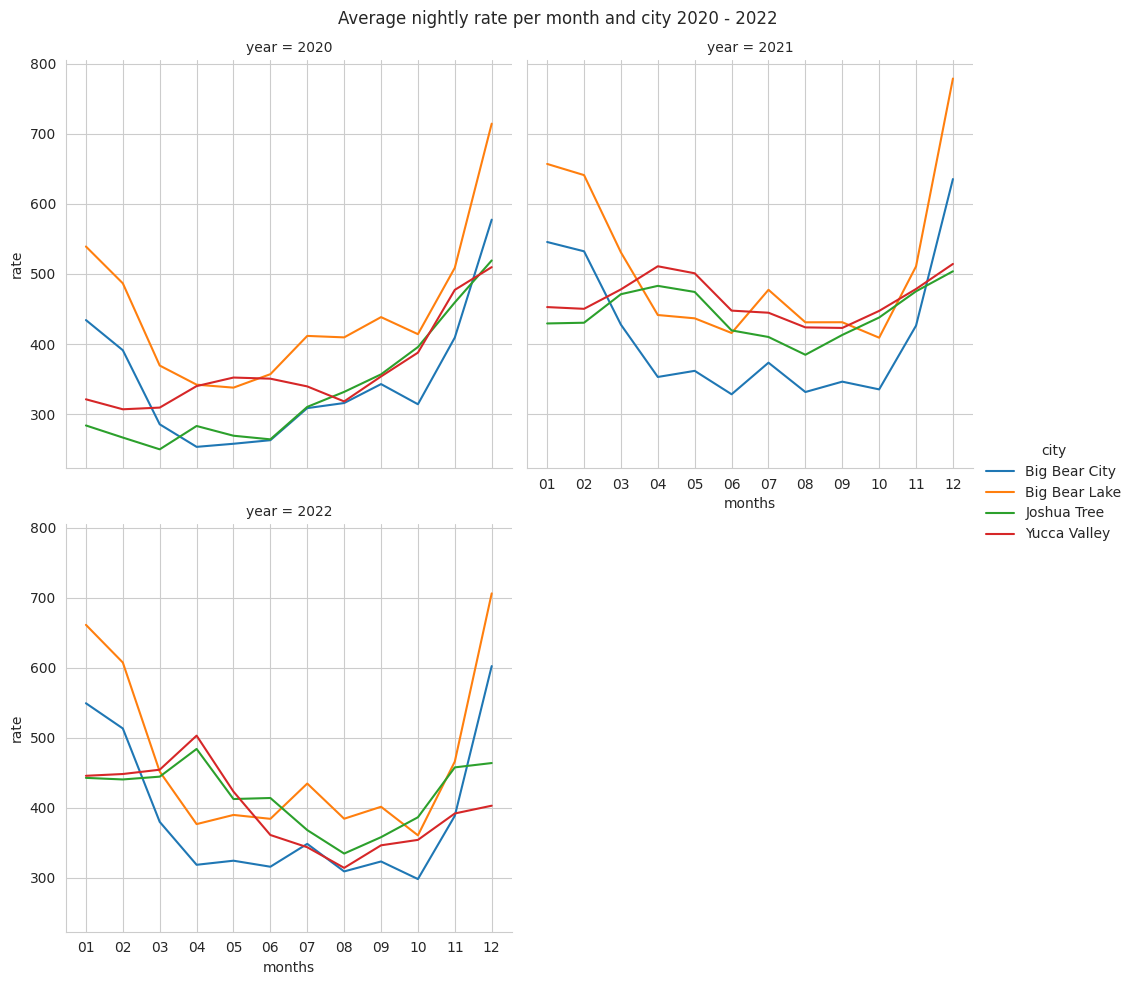

In [3]:
sns.set_style("whitegrid")
rel = sns.relplot(
    data=df,
    x='months',
    y='rate',
    hue='city',
    col='year',
    col_wrap=2,
    kind='line')

#plt.ylabel('Nightly Rate ($)')
rel.fig.subplots_adjust(top=0.93)

rel.fig.suptitle('Average nightly rate per month and city 2020 - 2022')

# Query 2 - Amenities
- What are the proportions of hot tub and pool ownership among listings in the four cities
- How does nightly rate compare between listings with either a pool, hot tub or both
- As the previous data highlighted the highest rates were recorded in December 2021, further data analyses focusses purely on market analysis from this month

## Data Handling

In [ ]:
df_amen = pd.read_csv('/home/james/Documents/analysis/sql/airbnb/tub_pool.csv')

df_amen = df_amen[df_amen['month'] == '2021-12'] # filter for December 2021 (highest average nightly rate)

df_amen.head()

,unified_id,month,hot_tub,pool,unified_id.1,month.1,zipcode,city,host_type,bedrooms,bathrooms,guests,revenue,openness,occupancy,nightly_rate,lead_time,length_stay
0,AIR10052559,2022-12,1,0,AIR10052559,2022-12,92315,Big Bear Lake,Professionals,3,2.5,8,24628.0,31,0.838710,947.230769,24.60,3.400
1,AIR10424683,2022-12,0,1,AIR10424683,2022-12,92315,Big Bear Lake,Professionals,3,2.0,8,4500.0,31,0.322581,450.000000,47.80,2.200
2,AIR10471190,2022-12,1,0,AIR10471190,2022-12,92314,Big Bear City,2-5 Units,3,2.0,8,8898.0,31,0.677419,423.714286,39.50,2.625
3,AIR10551482,2022-12,1,0,AIR10551482,2022-12,92314,Big Bear City,2-5 Units,5,4.0,15+,22700.0,31,0.612903,1194.736842,134.25,2.625
4,AIR11209785,2022-12,1,0,AIR11209785,2022-12,92314,Big Bear City,Single Owners,3,2.0,8,8651.0,27,0.740741,432.550000,33.75,2.625


## Share of Listings by their amenities

In [ ]:
df_amen['amenity'] = df_amen.apply(lambda value: 'both' if value['pool'] and value['hot_tub'] else 
                         ('pool' if value['pool'] else ('hot tub' if value['hot_tub'] else 'none')), axis=1)

<Axes: xlabel='city', ylabel='count'>

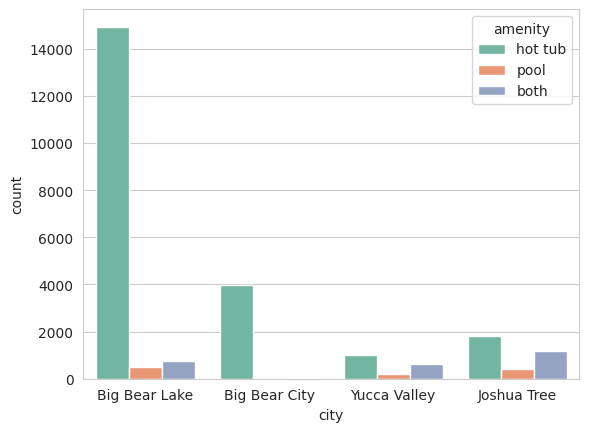

In [ ]:
sns.set_style('whitegrid')

sns.countplot(data=df_amen,
              x='city',
              hue='amenity',
              palette='Set2')

## Distribution of nightly rate based upon amenities

Text(0.5, 0, 'Nightly Rate ($)')

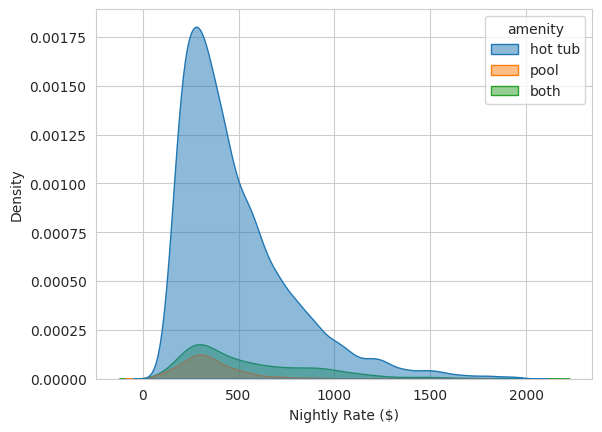

In [ ]:
sns.set_style('whitegrid')

sns.kdeplot(data=df_amen[df_amen['nightly_rate'] < 2000],
            x='nightly_rate',
            hue='amenity',
            fill=True,
            linewidth=1,
            alpha=0.5)

plt.xlabel('Nightly Rate ($)')

# Query 3 - Geospatial Analysis
- visualisation of airbnb listings in Big Bear Area

## Data Handling

In [ ]:
df_bear = pd.read_csv('/home/james/Documents/analysis/sql/airbnb/geoloc_market.csv')

df_bear = df_bear[df_bear['geo_month'] == '2021-12'] # select only values for Dec 2021

df_bear['amenity'] = df_bear.apply(lambda value: 'both' if value['pool'] and value['hot_tub'] else 
                     ('pool' if value['pool'] else ('hot tub' if value['hot_tub'] else 'none')), axis=1) # melt hot tub and pool bools into amenity

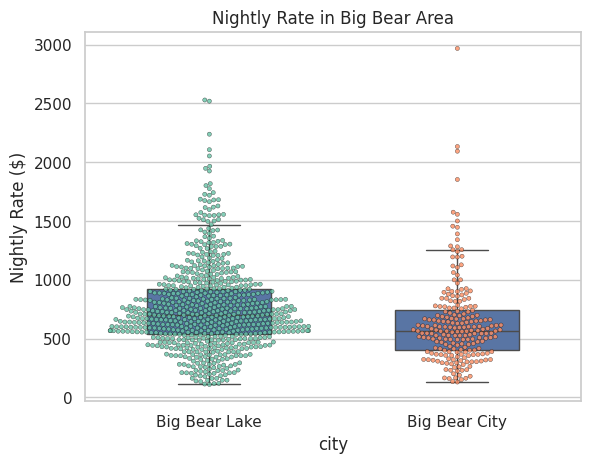

In [14]:
sns.set(style="whitegrid")

ax = sns.boxplot(x='city', y='nightly_rate', 
                 data=df_bear, 
                 showfliers =False,
                 width=0.5)

ax = sns.swarmplot(x='city', y='nightly_rate', 
                   data=df_bear, 
                   hue='city',
                   size=3,
                   alpha=0.8,
                   palette='Set2',
                   edgecolor='black',
                   linewidth=0.25)


plt.title('Nightly Rate in Big Bear Area')
plt.ylabel('Nightly Rate ($)')

plt.show()

## Handling outliers

In [15]:
# calculate iqr for nightly rate
rate = np.array(df_bear['nightly_rate'].dropna())

q1 = np.percentile(rate, 25)
q3 = np.percentile(rate, 75)
iqr = q3 - q1

# upper and lower bounds
low_b = q1 - 1.5*iqr
up_b = q3 + 1.5*iqr

print("interquartile range:\n", iqr)
print("q1\n", q1)
print("q3\n", q3)

print("lower bound\n", low_b)
print("upper bound\n", up_b)

interquartile range:
 386.65966385
q1
 500.0
q3
 886.65966385
lower bound
 -79.98949577500002
upper bound
 1466.649159625


In [16]:
df_filt = df_bear[(df_bear['nightly_rate'] <= up_b)] # filter for price lower than upper bound

## Visualisation

In [ ]:
print("max\n", df_bear[['longitude', 'latitude']].max())

#longitude   -116.78896
#latitude      34.29221

print("min\n", df_bear[['longitude', 'latitude']].min())

#longitude   -116.96050
#latitude      34.2242

max
 longitude   -116.78896
latitude      34.29221
dtype: float64
min
 longitude   -116.96050
latitude      34.22426
dtype: float64


In [17]:
projPC = ccrs.PlateCarree()
bear_latN = 34.29221
bear_latS = 34.22426
bear_lonW = -116.96050
bear_lonE =  -116.78896
bear_cLat = (bear_latN + bear_latS) / 2
bear_cLon = (bear_lonW + bear_lonE) / 2
projLccNY = ccrs.LambertConformal(central_longitude=bear_cLon, central_latitude=bear_cLat)

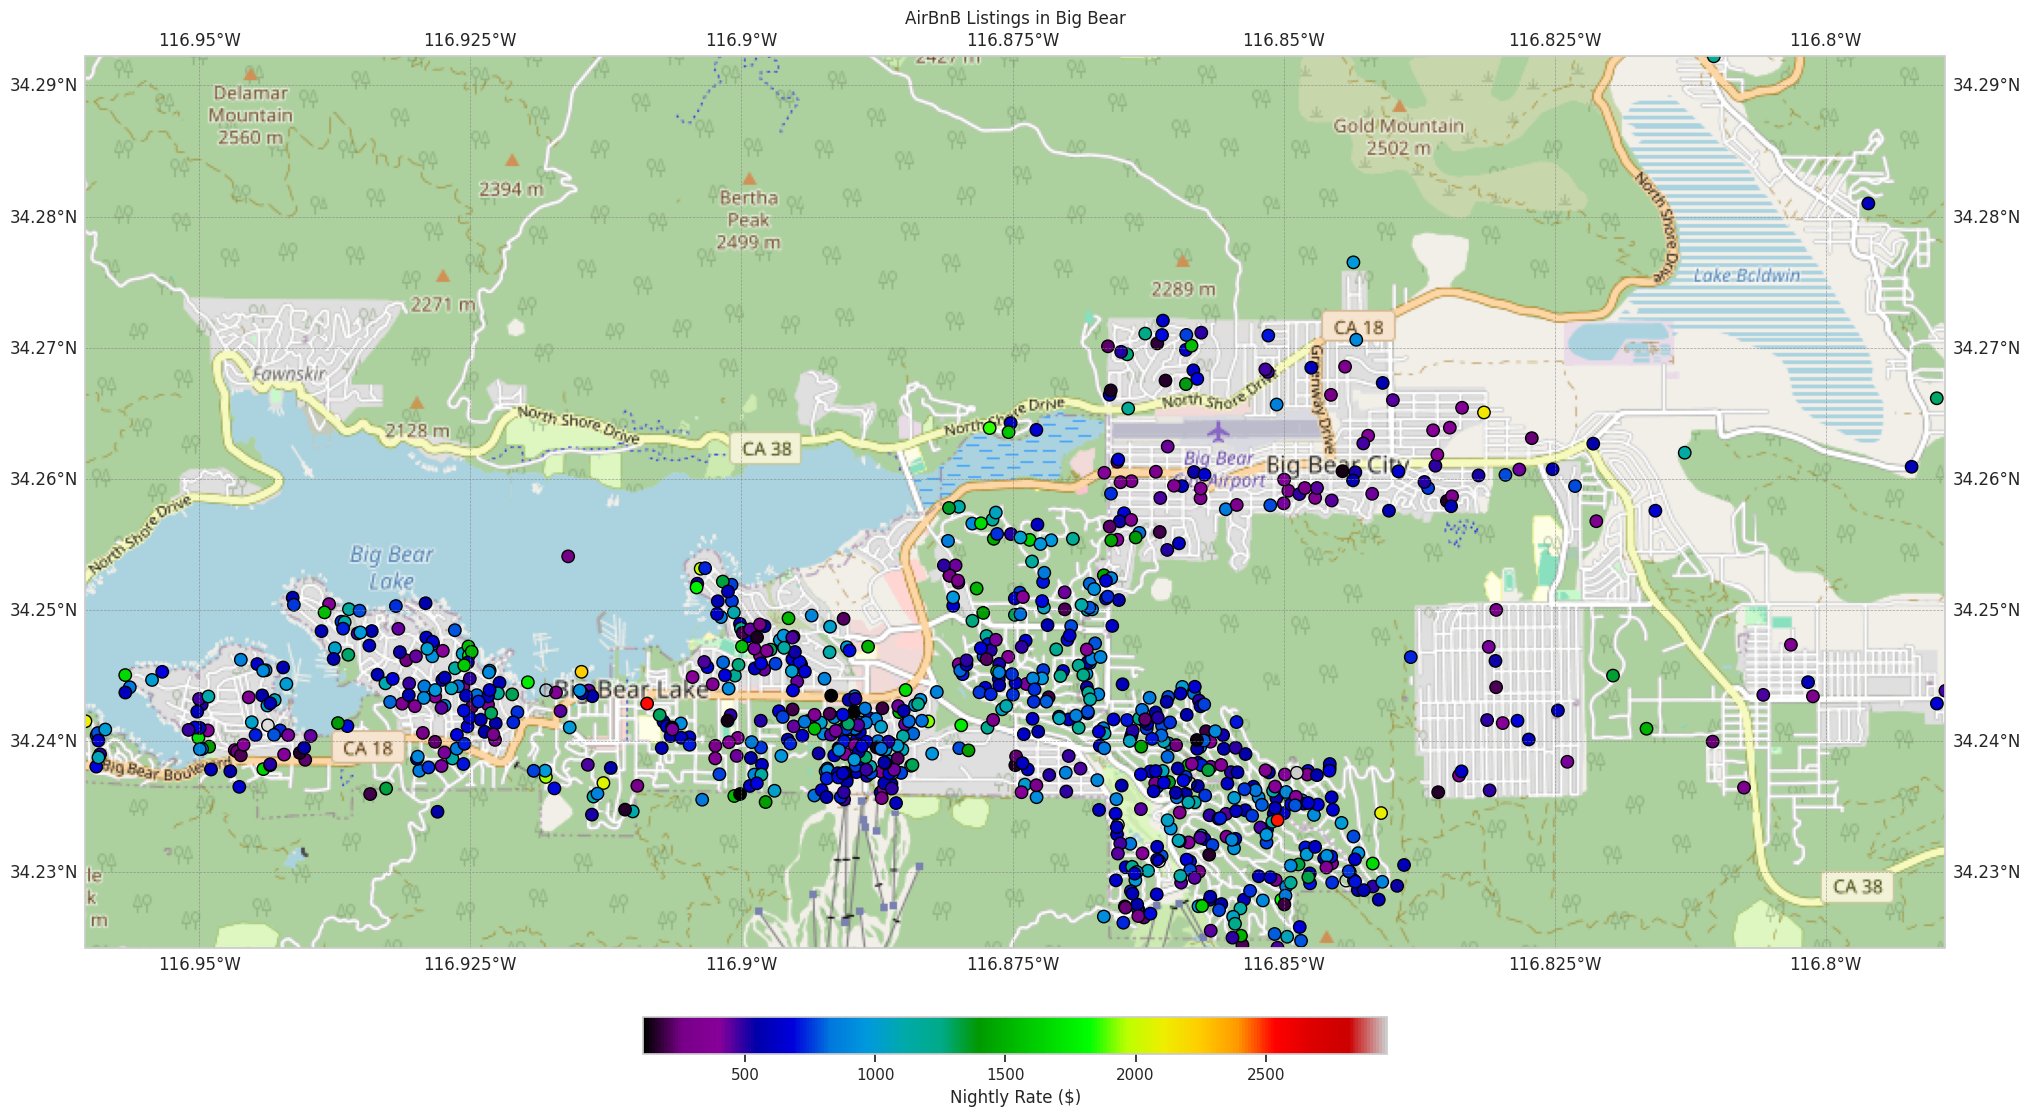

In [18]:
# unfiltered viz

osm_img = cimgt.OSM()

cmap=mpl.colormaps['nipy_spectral']

fig, ax = plt.subplots(figsize=(24, 18), subplot_kw={'projection': osm_img.crs}) # set up plot with map b/g
ax.set_extent([bear_lonW, bear_lonE, bear_latS, bear_latN], crs=ccrs.PlateCarree()) # set coordinate limits
ax.add_image(osm_img, 13)  # Zoom level
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--') # gridlines

ax.set_title('AirBnB Listings in Big Bear')

p = ax.scatter(df_bear['longitude'], 
           df_bear['latitude'], 
           transform=projPC,
           cmap=cmap,
           alpha=1,
           c=df_bear['nightly_rate'],
           edgecolors='black',
           #s=2*(df_bear['lead_time']),
           s=80,
           marker='o')
          #c= np.log10(df_bear['nightly_rate']), cmap=cmap)

fig.colorbar(p,ax=ax,orientation='horizontal',label='Nightly Rate ($)',
             shrink=0.4,
             pad=0.05)

plt.show()

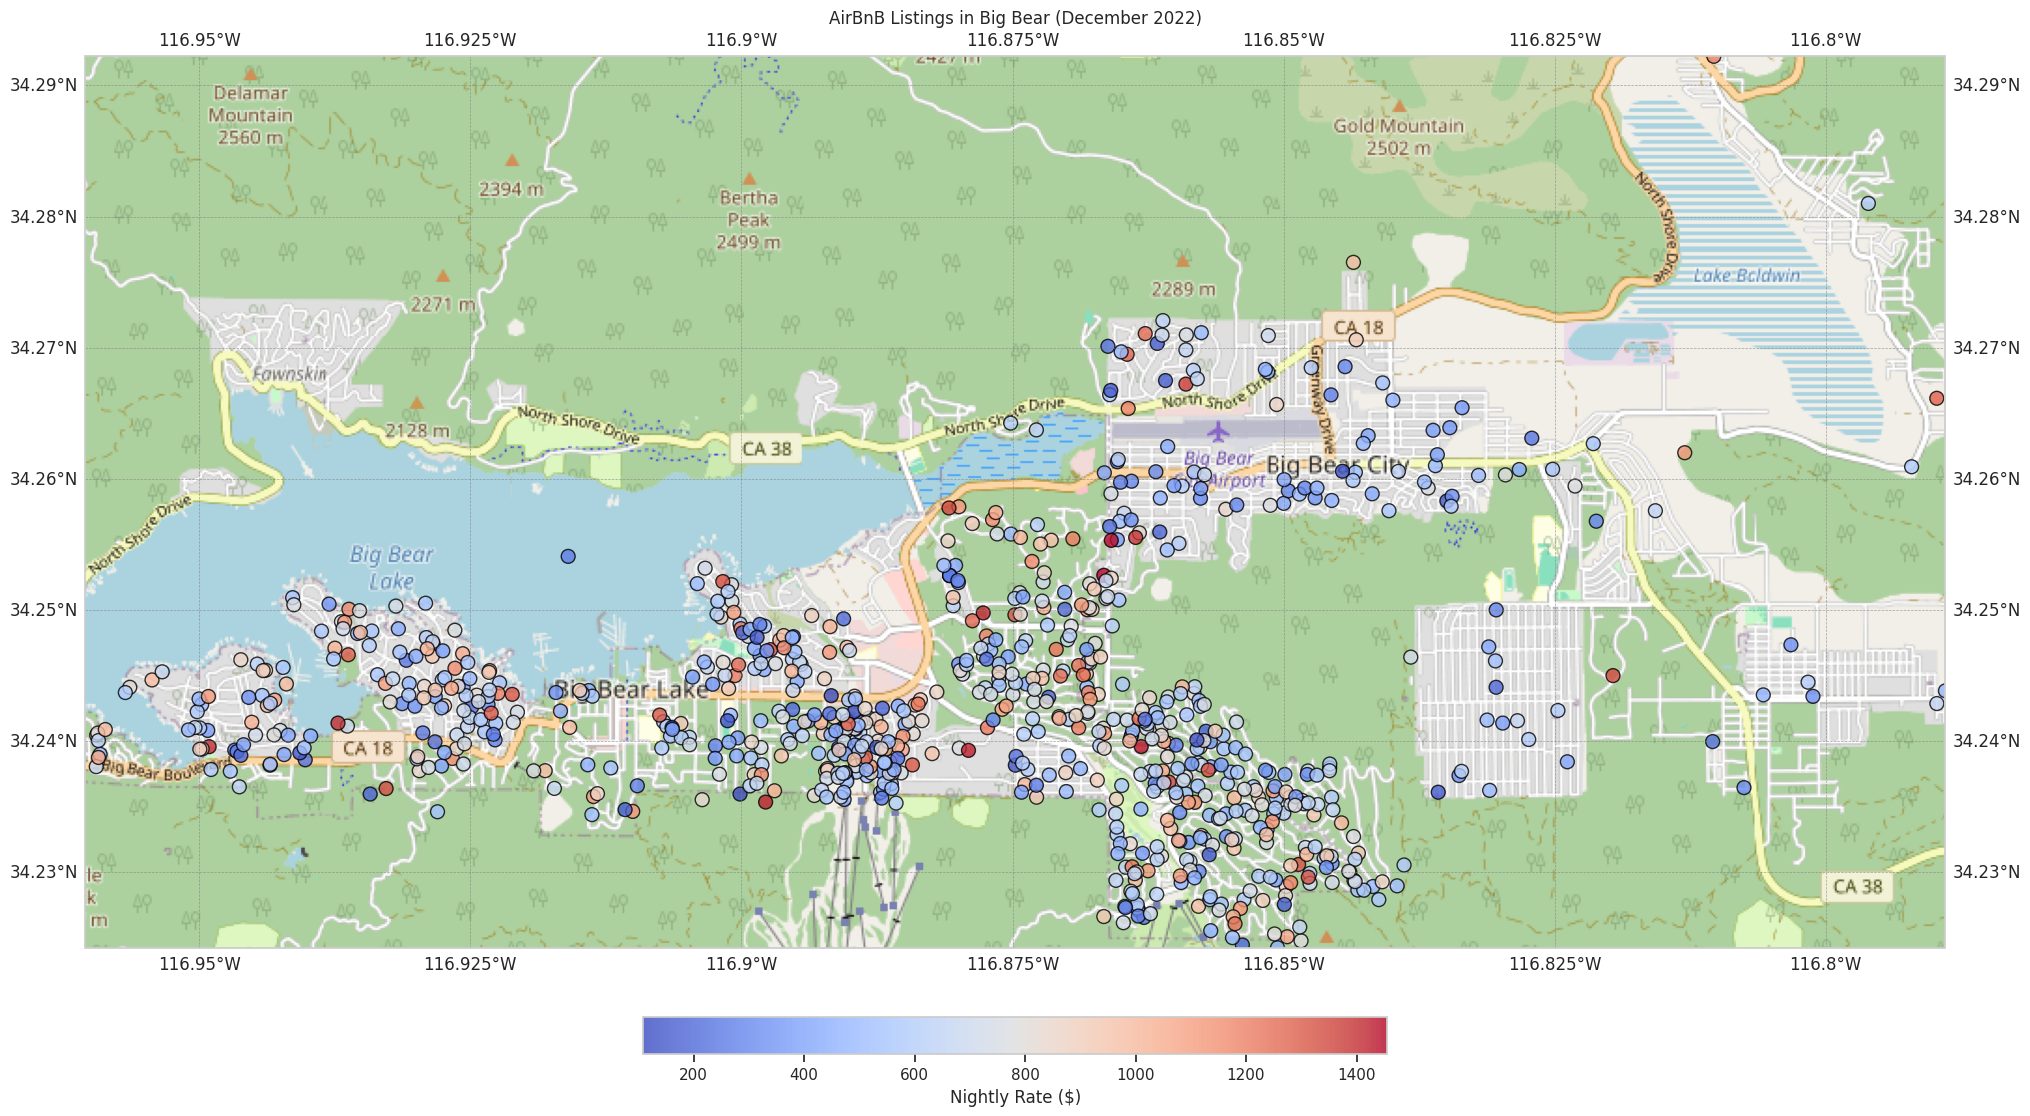

In [ ]:
# filtered viz

osm_img = cimgt.OSM()

cmap=mpl.colormaps['coolwarm']

fig, ax = plt.subplots(figsize=(24, 18), subplot_kw={'projection': osm_img.crs}) # set up plot with map b/g
ax.set_extent([bear_lonW, bear_lonE, bear_latS, bear_latN], crs=ccrs.PlateCarree()) # set coordinate limits
ax.add_image(osm_img, 13)  # Zoom level
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--') # gridlines

ax.set_title('AirBnB Listings in Big Bear (December 2021)')

p = ax.scatter(df_filt['longitude'], 
           df_filt['latitude'], 
           transform=projPC,
           cmap=cmap,
           alpha=0.8,
           c=df_filt['nightly_rate'],
           edgecolors='black',
           #s=2*(df_bear['lead_time']),
           s=100,
           marker='o')
          #c= np.log10(df_bear['nightly_rate']), cmap=cmap)

fig.colorbar(p,ax=ax,orientation='horizontal',label='Nightly Rate ($)',
             shrink=0.4,
             pad=0.05)

plt.show()

In [22]:
df_tub = df_filt[df_filt['amenity'] == 'hot tub']

df_pool = df_filt[df_filt['amenity'] == 'pool']

df_both = df_filt[df_filt['amenity'] == 'both']

df_none = df_filt[df_filt['amenity'] == 'none']

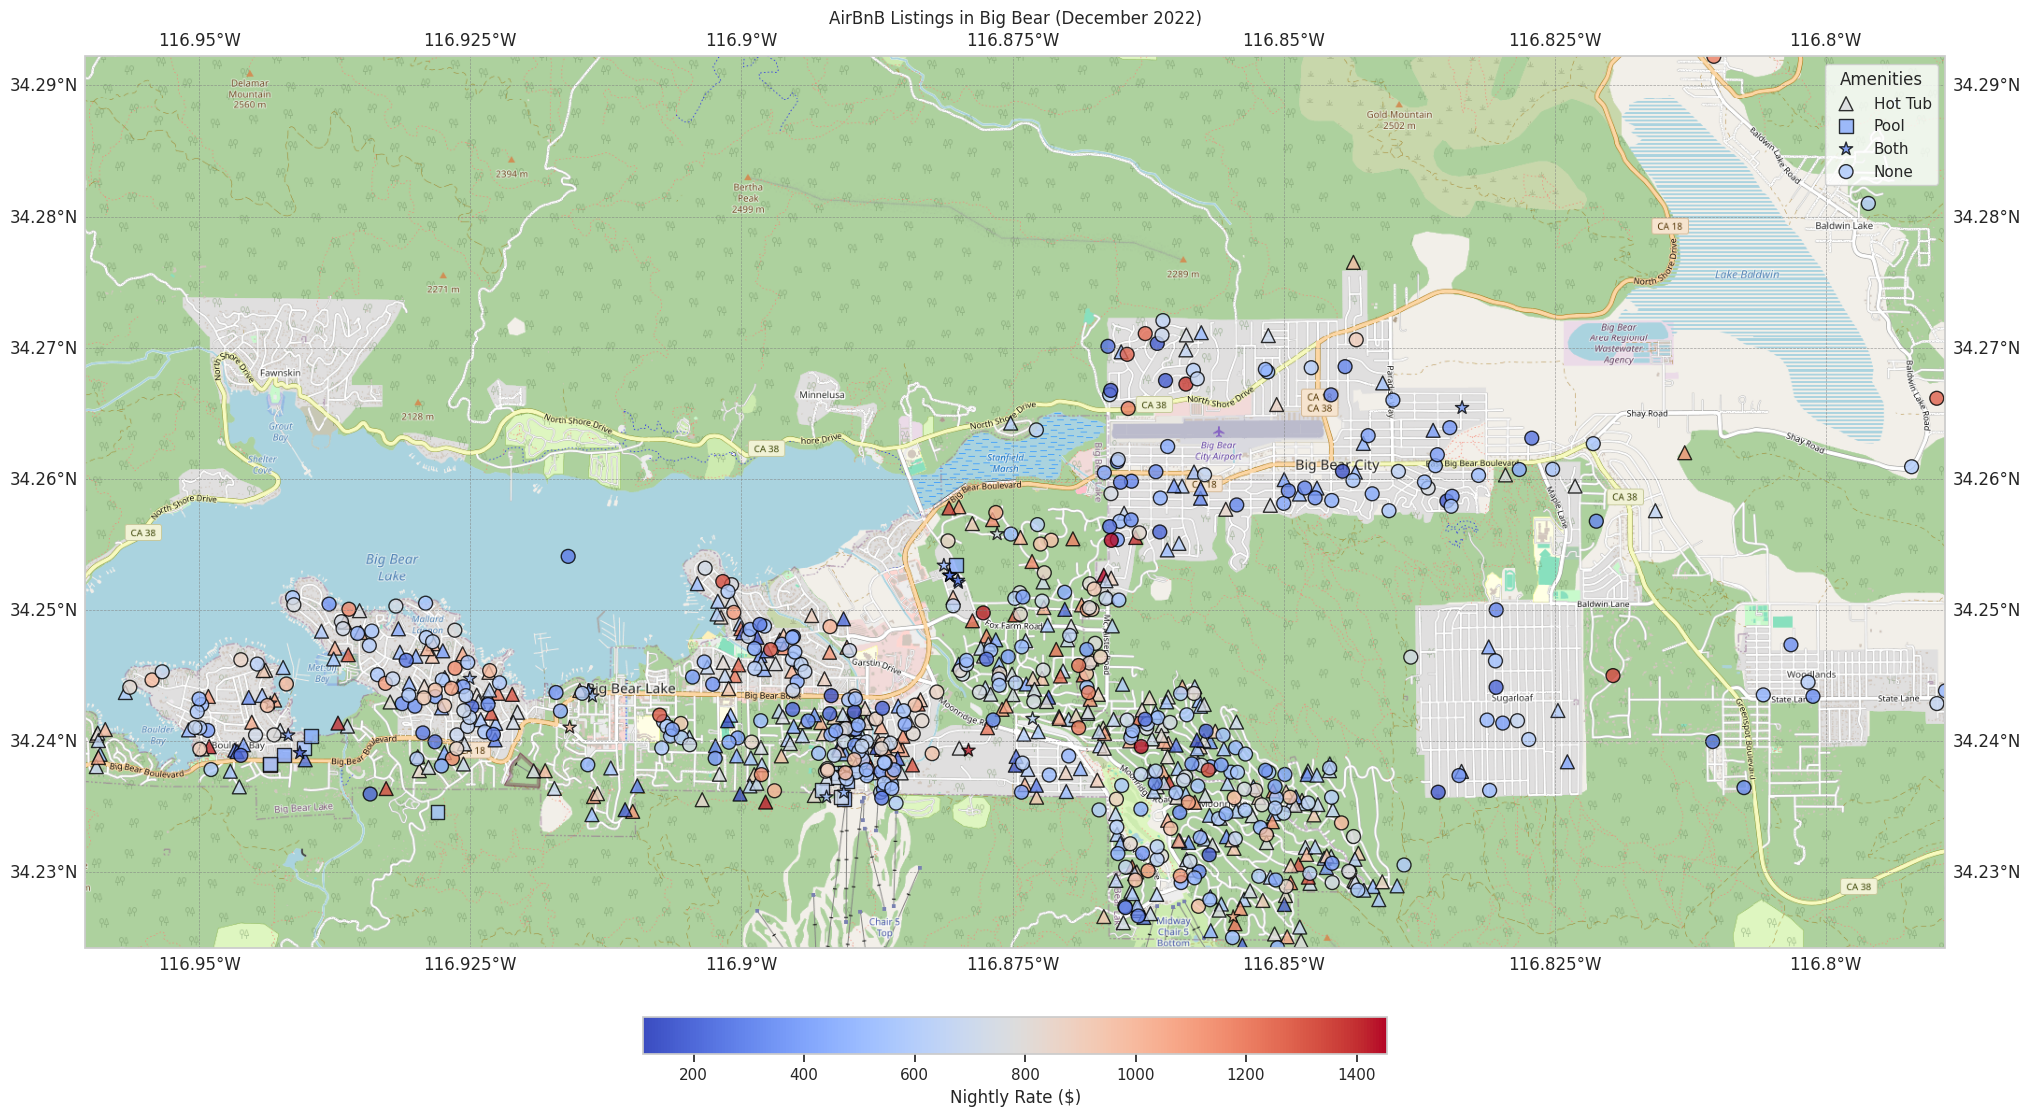

In [ ]:
# filtered viz by amenity type

## mapping color bar commonly
vmin = df_filt['nightly_rate'].min()
vmax = df_filt['nightly_rate'].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.colormaps['coolwarm']
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# open street map tiles
osm_img = cimgt.OSM()

# plot customisation
fig, ax = plt.subplots(figsize=(24, 18), subplot_kw={'projection': osm_img.crs}) # set up plot with map b/g
ax.set_extent([bear_lonW, bear_lonE, bear_latS, bear_latN], crs=ccrs.PlateCarree()) # set coordinate limits
ax.add_image(osm_img, 14)  # Zoom level
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--') # gridlines
ax.set_title('AirBnB Listings in Big Bear (December 2021)')

# scatter layer - listings w/ hot tub
p = ax.scatter(
    df_tub['longitude'], 
    df_tub['latitude'], 
    transform=projPC,
    c=df_tub['nightly_rate'],
    cmap='coolwarm',
    norm=norm,
    alpha=0.8,
    edgecolors='black',
    marker='^',
    s=100,
    label='Hot Tub'
)

# scatter layer - listings w/ pool
q = ax.scatter(
    df_pool['longitude'], 
    df_pool['latitude'], 
    transform=projPC,
    c=df_pool['nightly_rate'],
    norm=norm,
    cmap='coolwarm',
    alpha=0.8,
    edgecolors='black',
    marker='s',
    s=100,
    label='Pool'
)

# scatter layer - listings w/ both
r = ax.scatter(
    df_both['longitude'], 
    df_both['latitude'], 
    transform=projPC,
    c=df_both['nightly_rate'],
    cmap='coolwarm',
    norm=norm,
    alpha=0.8,
    edgecolors='black',
    marker='*',
    s=100,
    label='Both'
)

# scatter layer - listings w/ none
s = ax.scatter(
    df_none['longitude'], 
    df_none['latitude'], 
    transform=projPC,
    c=df_none['nightly_rate'],
    cmap='coolwarm',
    norm=norm,
    alpha=0.8,
    edgecolors='black',
    marker='o',
    s=100,
    label='None'
)

# shared, common colour bar
fig.colorbar(sm, ax=ax,orientation='horizontal',label='Nightly Rate ($)',
             shrink=0.4,
             pad=0.05)

# amenities marker legend
plt.show()